# iRAD Assam: exploratory data analysis

**Granica × IIT Guwahati Hackathon · Team Granica LATENT**

Input: the parsed iRAD output (`iRAD_output/iRAD_Assam_all__*.parquet`), produced by `iRAD_extraction/irad_to_excel.py` from 44,928 police accident-report PDFs.

**What this notebook is for.** We are not predicting crashes. The data will train and ground an AI component inside a bigger physical-AI system (lead concept: *"Speed-Breaker or Crash?"*, crash detection for phones, helmets and EV two-wheelers; backups: Rearview Guardian, Adversary Engine, RealStar). So the questions are:

1. **Can we trust it?** Provenance, coverage, completeness, field reliability, contradictions.
2. **What happens?** Crash modes, vehicle pairs, when, where, conditions: the *target classes* an AI must recognise.
3. **Two-wheelers.** They are 69% of Assam's registered fleet. How do they crash, who hits them, and how are riders hurt?
4. **What happens after the crash?** Reporting delay, hospitalisation mode and delay, hours to death: the *value* of an automatic alert.
5. **Kinematic and mechanical hints.** Speed violations, speed limits, skid marks, inspection items: what the data can and cannot say about motion.

**Privacy:** no names, phone numbers, addresses, registration numbers or narratives are printed. Aggregates only.

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 60)

DATA = os.environ.get('IRAD_DIR', '../iRAD_output')          # folder with iRAD_Assam_all__*.parquet
OUT  = os.environ.get('EDA_OUT', 'eda_outputs'); os.makedirs(f'{OUT}/figs', exist_ok=True)
def load(name): return pd.read_parquet(f'{DATA}/iRAD_Assam_all__{name}.parquet')

A  = load('Accidents'); V = load('Vehicles'); D = load('Drivers')
P  = load('Passengers'); PE = load('Pedestrians'); T = load('Transport_Inspections')
RD = load('Road_Details'); FL = load('Files_Log'); VI = load('Validation_Issues'); SM = load('Summary')
KEY = {}                                                      # headline numbers, saved to JSON at the end

# chart style: one hue for single series (slot-1 blue), light grid, thin marks
BLUE, ORANGE, AQUA, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#8c8b85'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': .6, 'axes.axisbelow': True,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold', 'font.size': 9})
def save(fig, name): fig.tight_layout(); fig.savefig(f'{OUT}/figs/{name}.png', bbox_inches='tight'); plt.show()
def pct(x): return round(100 * float(x), 1)
print({k: len(v) for k, v in dict(Accidents=A, Vehicles=V, Drivers=D, Passengers=P, Pedestrians=PE,
                                  Transport=T, Road_Details=RD, Files=FL, Issues=VI).items()})

{'Accidents': 44114, 'Vehicles': 56185, 'Drivers': 56083, 'Passengers': 22098, 'Pedestrians': 11199, 'Transport': 29507, 'Road_Details': 5730, 'Files': 44928, 'Issues': 40594}


## 1. Provenance and parse quality

In [2]:
print(SM.to_string(index=False))
st = FL.status.str.replace(r':.*', '', regex=True).value_counts()
KEY.update(pdf_files=int(len(FL)), accidents_kept=int((FL.status=='kept').sum()),
           duplicates=int(FL.status.str.startswith('duplicate').sum()), parse_errors=int(FL.status.str.startswith('error').sum()),
           verify_cells=int(SM.set_index('item').loc['verify_cells_rechecked','value']),
           verify_missing=int(SM.set_index('item').loc['verify_cells_not_found_in_pdf','value']))
print('\n', FL.status.value_counts().to_string())

                                        item                                                                                    value
                                generated_at                                                                      2026-09-26 04:58:42
                              parser_version                                                                                    1.0.0
                                input_folder                                                                               D:\DataSet
                             pdf_files_found                                                                                    44928
         files_duplicate (identical content)                                                                                      651
files_duplicate (superseded by newer report)                                                                                        4
                                 files_error                  

In [3]:
# completeness tiers: which sections each report actually contains
sec = A.sections_present.fillna('')
tier = np.select([sec.str.contains('Transport Details'), sec.str.contains('Vehicle Details')],
                 ['full (with transport inspection)', 'medium (vehicles/persons)'], 'skeletal (accident summary only)')
A['form_tier'] = tier
t = A.form_tier.value_counts(normalize=True).mul(100).round(1)
print(t.to_string()); KEY['form_tier_pct'] = t.to_dict()
print('\npages per report:', A.pages.describe()[['min','50%','max']].to_dict())

form_tier
full (with transport inspection)    47.1
medium (vehicles/persons)           37.3
skeletal (accident summary only)    15.5

pages per report: {'min': 2.0, '50%': 8.0, 'max': 49.0}


## 2. Coverage: time and place

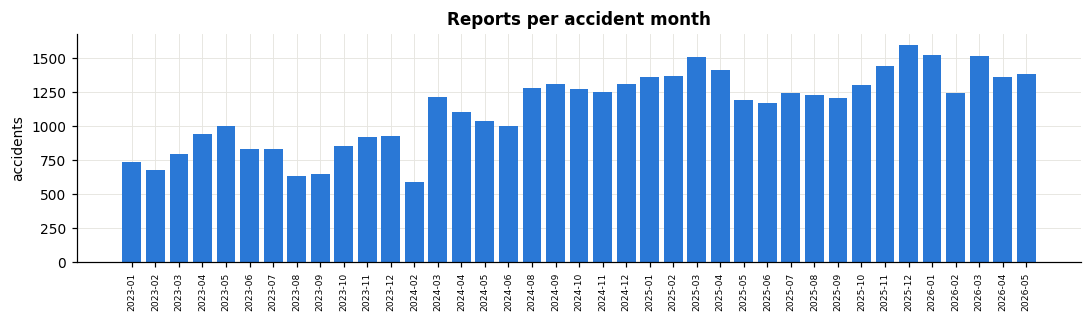

accident_year
2023.0     9777
2024.0    11331
2025.0    15991
2026.0     7014
range: 2023-01-01 01:30:00 → 2026-05-31 23:55:00


In [4]:
A['ym'] = A.accident_datetime.dt.to_period('M')
m = A.groupby('ym').size()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(m.index.astype(str), m.values, color=BLUE, width=.8)
ax.set_title('Reports per accident month'); ax.set_ylabel('accidents'); ax.tick_params(axis='x', rotation=90, labelsize=6)
save(fig, '01_reports_per_month')
y = A.accident_year.value_counts().sort_index(); print(y.to_string())
print('range:', A.accident_datetime.min(), '→', A.accident_datetime.max())
KEY['years'] = {int(k): int(v) for k, v in y.items()}

In [5]:
# official Assam totals for comparison (MoRTH: 2023 = 7,421 accidents; Jun-2022–Nov-2024 = 27,214 reported to Parliament)
iy = A.groupby('accident_year').size()
print('iRAD 2023 accidents:', int(iy.get(2023, 0)), '| MoRTH 2023 Assam total: 7,421 →',
      f"ratio {iy.get(2023,0)/7421:.2f}")
KEY['irad_2023_vs_morth_ratio'] = round(float(iy.get(2023, 0)) / 7421, 2)
# deaths are the most comparable quantity: MoRTH 2023 Assam deaths = 3,296
k23 = int(A.loc[A.accident_year == 2023, 'killed_total'].sum())
print('iRAD 2023 persons killed:', k23, '| MoRTH 2023 Assam deaths: 3,296 → coverage', f'{k23/3296:.0%}')
print('2023 severity mix:', A.loc[A.accident_year == 2023, 'severity'].value_counts().to_dict())
KEY['irad_2023_deaths'] = k23; KEY['irad_2023_death_coverage_vs_morth'] = round(k23 / 3296, 3)

iRAD 2023 accidents: 9777 | MoRTH 2023 Assam total: 7,421 → ratio 1.32
iRAD 2023 persons killed: 3237 | MoRTH 2023 Assam deaths: 3,296 → coverage 98%
2023 severity mix: {'Grievous Injury': 4588, 'Fatal': 2924, 'Minor Injury Hospitalized': 1011, 'No Injury': 969, 'Minor Injury Non Hospitalized': 285}


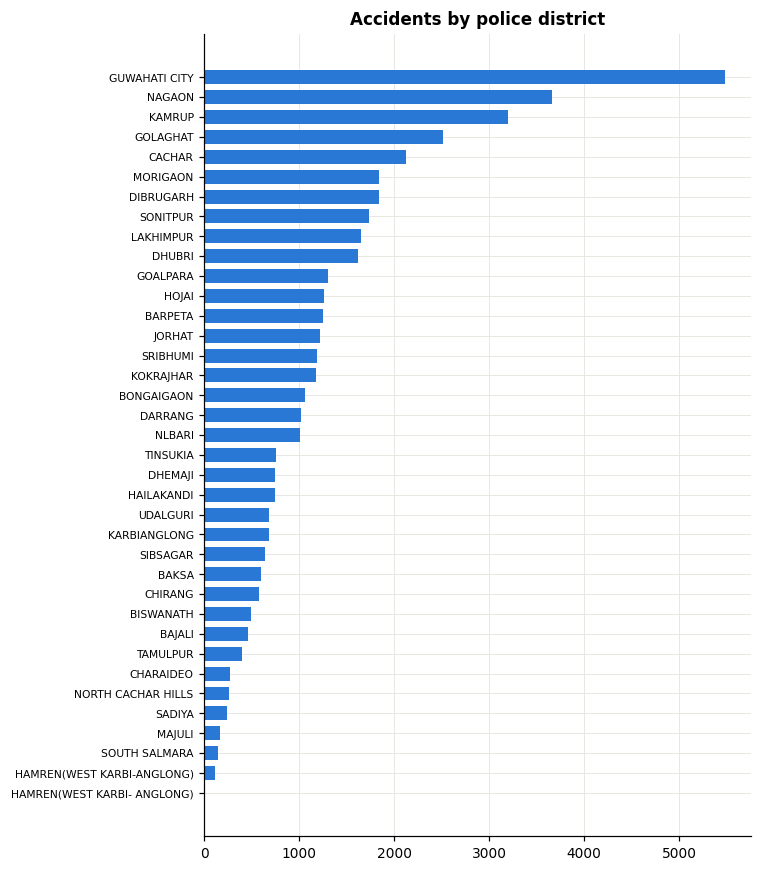

37 district labels; top 5 share: 38.5 %


In [6]:
d = A.district_name.str.upper().str.strip().value_counts()
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(d.index[::-1], d.values[::-1], color=BLUE, height=.7); ax.set_title('Accidents by police district'); ax.tick_params(axis='y', labelsize=7)
save(fig, '02_districts')
print(len(d), 'district labels; top 5 share:', pct(d.head(5).sum() / d.sum()), '%')

{'zero_zero': 1, 'inside_assam_pct': 100.0, 'coords_reused_5plus': 0, 'accidents_on_reused_coords': 0}


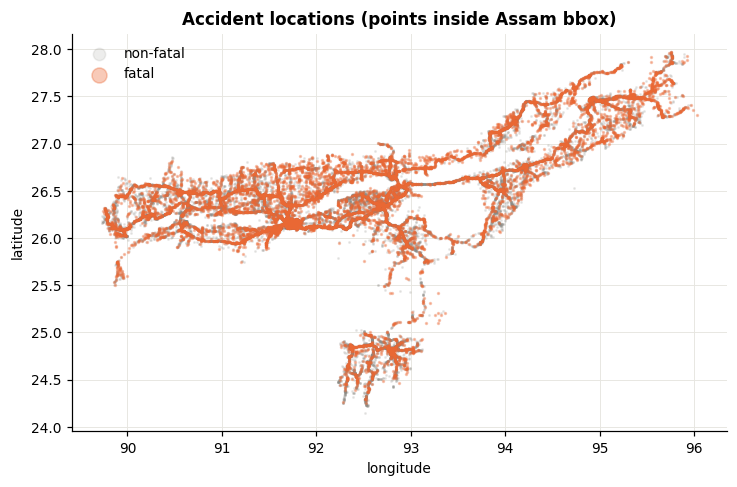

In [7]:
# geolocation sanity
lat, lon = A.latitude, A.longitude
zero = (lat == 0) & (lon == 0)
inside = lat.between(24.0, 28.3) & lon.between(89.6, 96.2)
coord_counts = A.loc[~zero].groupby([lat.round(5), lon.round(5)]).size()
stacked = coord_counts[coord_counts >= 5]
geo = dict(zero_zero=int(zero.sum()), inside_assam_pct=pct(inside.mean()),
           coords_reused_5plus=int(len(stacked)), accidents_on_reused_coords=int(stacked.sum()))
print(geo); KEY['geo'] = geo
fig, ax = plt.subplots(figsize=(8, 4.5))
g = A[inside]; sev = g.severity.eq('Fatal')
ax.scatter(g.longitude[~sev], g.latitude[~sev], s=1, alpha=.15, color=GREY, label='non-fatal')
ax.scatter(g.longitude[sev], g.latitude[sev], s=1.5, alpha=.35, color=ORANGE, label='fatal')
ax.set_title('Accident locations (points inside Assam bbox)'); ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.legend(markerscale=8, frameon=False); ax.set_aspect('equal'); save(fig, '03_map')

In [8]:
# ~100 m hotspot cells (lat/lon rounded to 3 decimals)
cell = A.groupby([A.latitude.round(3), A.longitude.round(3)]).agg(n=('accident_id', 'size'),
        fatal=('severity', lambda s: (s == 'Fatal').sum()), district=('district_name', 'first')).sort_values('n', ascending=False)
hot = cell[cell.n >= 5]
KEY['hotspots_100m'] = {'cells_with_5plus': int(len(hot)), 'accidents_in_them': int(hot.n.sum()), 'share_pct': pct(hot.n.sum() / len(A))}
print(KEY['hotspots_100m']); display(cell.head(10)); hot.reset_index().to_csv(f'{OUT}/hotspot_cells_100m.csv', index=False)

{'cells_with_5plus': 567, 'accidents_in_them': 3821, 'share_pct': 8.7}


,,n,fatal,district
latitude,longitude,,,
26.142,91.676,41,7,GUWAHATI CITY
26.155,91.676,25,1,GUWAHATI CITY
26.150,91.785,24,5,GUWAHATI CITY
26.116,91.719,19,4,GUWAHATI CITY
26.152,91.677,19,4,GUWAHATI CITY
26.162,91.772,19,2,GUWAHATI CITY
26.254,91.692,18,2,KAMRUP
26.274,91.512,17,6,KAMRUP
26.126,91.680,16,4,GUWAHATI CITY


## 3. Field reliability map

For each decision-relevant field, what share of accidents or persons has a **usable** value, versus blank, "Not Known" or "Not Applicable"? This tells us which fields an AI can learn from and which must be measured or inferred elsewhere (the core argument of v3/v5).

,blank %,not known / vague %,usable %
T.speed_limiter_device,89.8,4.4,5.8
T.reflective_tapes,88.4,0.0,11.6
T.lights_functional,72.9,0.0,27.1
T.accident_due_to,1.1,69.8,29.1
T.vlt_device,1.8,63.4,34.8
D.cell_phone_while_driving,3.8,59.3,36.9
D.seatbelt_helmet,6.9,50.2,42.8
D.drunk_driving,3.6,49.9,46.5
A.initial_observation,12.6,19.6,67.8
D.licence_type,5.7,18.8,75.5


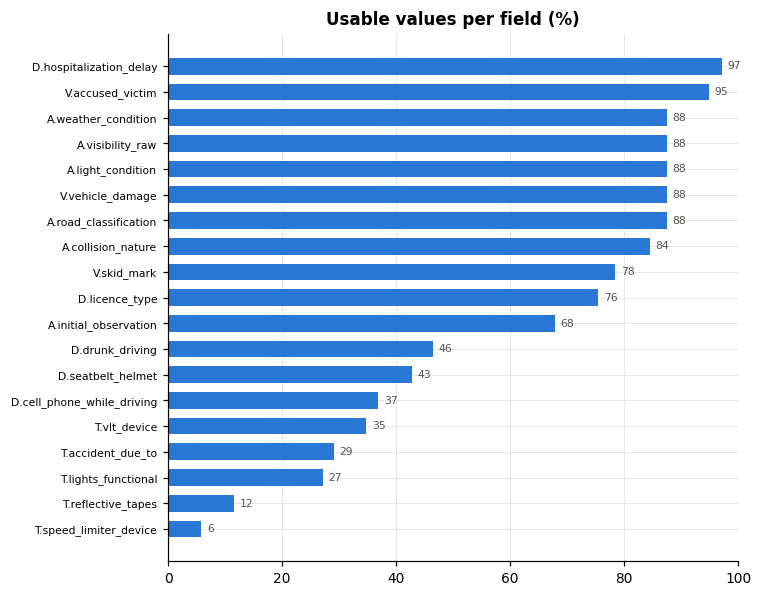

visibility options: {'100 meters': 11420, '50 meters': 8234, '25 meters': 7049, '75 meters': 6099, '15 meters': 5787}


In [9]:
def reliab(df, col, bad=('Not Known', 'Unknown', 'Not Available', 'Under Investigation/ Observation')):
    s = df[col]
    return pd.Series({'blank %': pct(s.isna().mean()), 'not known / vague %': pct(s.isin(bad).mean()),
                      'usable %': pct((~s.isna() & ~s.isin(bad)).mean())})
rows = {
 'A.collision_nature': reliab(A, 'collision_nature'), 'A.light_condition': reliab(A, 'light_condition'),
 'A.weather_condition': reliab(A, 'weather_condition'), 'A.visibility_raw': reliab(A, 'visibility_raw'),
 'A.initial_observation': reliab(A, 'initial_observation'), 'A.road_classification': reliab(A, 'road_classification'),
 'V.accused_victim': reliab(V, 'accused_victim'), 'V.vehicle_damage': reliab(V, 'vehicle_damage'),
 'V.skid_mark': reliab(V, 'skid_mark'), 'D.seatbelt_helmet': reliab(D, 'seatbelt_helmet'),
 'D.cell_phone_while_driving': reliab(D, 'cell_phone_while_driving'), 'D.drunk_driving': reliab(D, 'drunk_driving'),
 'D.hospitalization_delay': reliab(D, 'hospitalization_delay'), 'D.licence_type': reliab(D, 'licence_type'),
 'T.speed_limiter_device': reliab(T, 'speed_limiter_device'), 'T.vlt_device': reliab(T, 'vlt_device'),
 'T.reflective_tapes': reliab(T, 'reflective_tapes'), 'T.lights_functional': reliab(T, 'lights_functional'),
 'T.accident_due_to': reliab(T, 'accident_due_to', bad=('Opinion cannot be given', 'Not Known')),
}
REL = pd.DataFrame(rows).T.sort_values('usable %'); display(REL)
REL.to_csv(f'{OUT}/field_reliability.csv'); KEY['field_reliability_usable_pct'] = REL['usable %'].to_dict()
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(REL.index, REL['usable %'], color=BLUE, height=.65); ax.set_xlim(0, 100)
ax.set_title('Usable values per field (%)'); ax.tick_params(axis='y', labelsize=7)
for i, v in enumerate(REL['usable %']): ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=7, color='#52514e')
save(fig, '04_field_reliability')
print('visibility options:', A.visibility_raw.value_counts().to_dict())

## 4. When: hour, month, light, weather

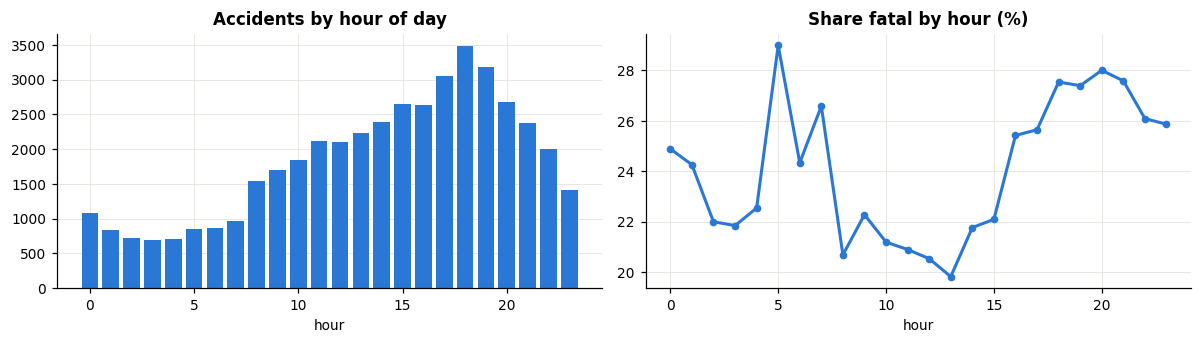

fatal share night vs day: 26.3 23.2


In [10]:
h = A.dropna(subset=['accident_hour']).groupby('accident_hour').agg(n=('accident_id', 'size'),
                                                                     fatal=('severity', lambda s: (s == 'Fatal').mean()))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].bar(h.index, h.n, color=BLUE, width=.8); axs[0].set_title('Accidents by hour of day'); axs[0].set_xlabel('hour')
axs[1].plot(h.index, h.fatal * 100, color=BLUE, lw=2, marker='o', ms=4); axs[1].set_title('Share fatal by hour (%)'); axs[1].set_xlabel('hour')
save(fig, '05_hour')
night_hours = h.index.isin(list(range(19, 24)) + list(range(0, 6)))
KEY['fatal_share_night_19_05'] = pct((A[A.accident_hour.isin(list(range(19,24))+list(range(0,6)))].severity == 'Fatal').mean())
KEY['fatal_share_day_06_18'] = pct((A[A.accident_hour.between(6, 18)].severity == 'Fatal').mean())
print('fatal share night vs day:', KEY['fatal_share_night_19_05'], KEY['fatal_share_day_06_18'])

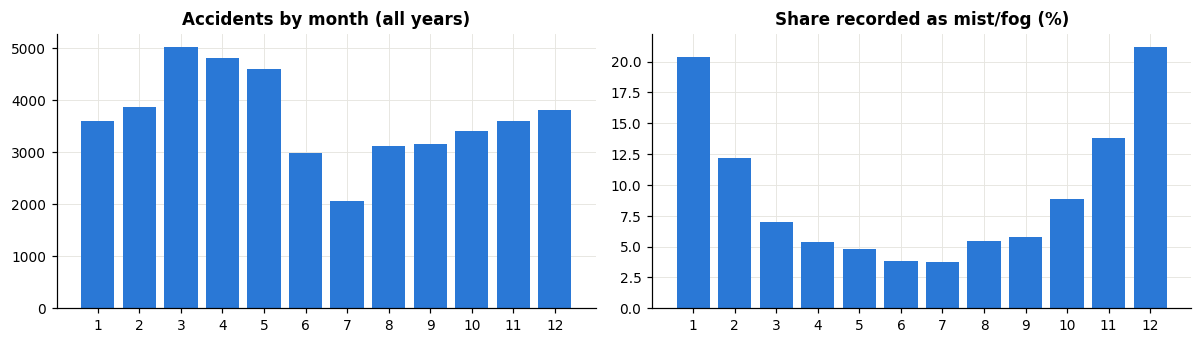

,n,fatal_pct
light_condition,,
Darkness with No street light,1029,35.2
Twilight,2469,30.1
Dawn,745,27.9
Night,13946,27.9
Darkness with Poor street light,207,25.6
Day,19737,23.3
Darkness with street lights on,460,18.9


,n,fatal_pct
weather_condition,,
Smoke/Dust,406,31.5
Cloudy,2341,29.4
Mist/ Fog,3976,28.5
Heavy Rain,281,25.6
Sunny / Clear,29668,25.0
Light Rain,1276,22.8


In [11]:
mo = A.groupby('accident_month').agg(n=('accident_id', 'size'), fog=('weather_condition', lambda s: s.fillna('').str.contains('Fog').mean()))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].bar(mo.index, mo.n, color=BLUE, width=.8); axs[0].set_title('Accidents by month (all years)'); axs[0].set_xticks(range(1, 13))
axs[1].bar(mo.index, mo.fog * 100, color=BLUE, width=.8); axs[1].set_title('Share recorded as mist/fog (%)'); axs[1].set_xticks(range(1, 13))
save(fig, '06_month_fog')
def sev_table(col, df=A, min_n=150):
    g = df.groupby(col).agg(n=('accident_id', 'size'), fatal_pct=('severity', lambda s: pct((s == 'Fatal').mean())))
    return g[g.n >= min_n].sort_values('fatal_pct', ascending=False)
display(sev_table('light_condition')); display(sev_table('weather_condition'))

In [12]:
# contradiction: 'Sunny / Clear' recorded with Night / darkness
dark = A.light_condition.fillna('').str.contains('Night|Darkness')
sunny_dark = dark & A.weather_condition.fillna('').str.contains('Sunny')
KEY['sunny_at_night_pct_of_dark'] = pct(sunny_dark.sum() / dark.sum())
print('"Sunny / Clear" among night/darkness accidents:', KEY['sunny_at_night_pct_of_dark'], '%  (likely means "clear")')

"Sunny / Clear" among night/darkness accidents: 59.6 %  (likely means "clear")


## 5. What happens: crash modes and vehicle pairs

In [13]:
display(sev_table('collision_nature', min_n=200)); display(sev_table('collision_type', min_n=200))
display(sev_table('road_classification', min_n=100))

,n,fatal_pct
collision_nature,,
Hit from Back,12093,32.2
"Hit from Side, Hit from Back",507,29.2
Skidding / Overturn,444,27.9
Run off Road,391,25.8
Head on Collision,8320,25.7
Hit tree,616,23.4
"Hit from Side, Head on Collision",306,22.9
Hit from Side,8027,21.5
Hit Parked Vehicle,410,21.2


,n,fatal_pct
collision_type,,
Vehicle to Pedestrian,9158,38.3
Vehicle to Bicycle,2276,33.6
Vehicle to Vehicle,17208,21.2
Fallen down while Boarding / Alighting,1179,20.4
Vehicle to Object / Property,3929,19.8
Vehicle to Animal,372,19.1
No Collision,3528,19.0
Vehicle to Tricycle,219,14.2


,n,fatal_pct
road_classification,,
Village Road,6534,31.7
State Highway,4627,26.5
Local Road,1700,26.4
National Highway,17679,25.2
Other District Road,2954,24.8
Sub-Arterial Road,104,22.1
Expressway,114,20.2
Major District Road,4647,19.9
Arterial Road,186,19.4


In [14]:
# vehicle-pair configurations for 2-vehicle crashes (scenario-bank style) + single-vehicle and pedestrian crashes
vt_map = {'Two Wheeler': '2W', 'Car/Jeep/Van/Taxi': 'Car', 'Truck/Lorry': 'Truck', 'Auto Rickshaw': 'Auto',
          'Bus': 'Bus', 'Bicycle': 'Bicycle', 'Tempo/Tractor': 'Tractor', 'Others': 'Other'}
V['vt'] = V.vehicle_type.map(vt_map).fillna('Other')
nveh = V.groupby('accident_id').size()
A['n_veh'] = A.accident_id.map(nveh).fillna(0).astype(int)
two = V[V.accident_id.isin(nveh[nveh == 2].index)]
pairs = two.groupby('accident_id').vt.apply(lambda s: ' – '.join(sorted(s)))
A['pair'] = A.accident_id.map(pairs)
cfg = A[A.n_veh == 2].groupby(['pair', 'collision_nature']).agg(n=('accident_id', 'size'),
        fatal_pct=('severity', lambda s: pct((s == 'Fatal').mean()))).reset_index()
cfg = cfg.sort_values('n', ascending=False)
top = cfg.head(15); display(top); top.to_csv(f'{OUT}/top_two_vehicle_configurations.csv', index=False)
single = A[A.n_veh == 1]
sv = single.merge(V[['accident_id', 'vt']], on='accident_id').groupby(['vt', 'collision_type']).agg(
     n=('accident_id', 'size'), fatal_pct=('severity', lambda s: pct((s == 'Fatal').mean()))).reset_index().sort_values('n', ascending=False)
print('single-vehicle crash configurations (incl. vehicle→pedestrian):'); display(sv.head(12))
KEY['vehicles_per_accident'] = A.n_veh.value_counts(normalize=True).mul(100).round(1).head(5).to_dict()

,pair,collision_nature,n,fatal_pct
84,2W – Car,Head on Collision,1274,22.3
0,2W – 2W,Head on Collision,1215,23.0
95,2W – Car,Hit from Back,1052,29.7
99,2W – Car,Hit from Side,914,14.7
8,2W – 2W,Hit from Back,862,37.9
178,2W – Truck,Hit from Back,644,45.2
14,2W – 2W,Hit from Side,617,17.2
418,Car – Truck,Hit from Back,503,8.3
126,2W – Other,Head on Collision,430,31.6
169,2W – Truck,Head on Collision,427,46.1


single-vehicle crash configurations (incl. vehicle→pedestrian):


,vt,collision_type,n,fatal_pct
26,2W,Vehicle to Pedestrian,4757,32.9
91,Car,Vehicle to Pedestrian,1616,41.2
85,Car,Vehicle to Object / Property,1577,7.0
2,2W,No Collision,1350,28.4
20,2W,Vehicle to Object / Property,1165,46.3
115,Other,Vehicle to Pedestrian,1004,50.1
74,Car,No Collision,723,7.5
149,Truck,Vehicle to Pedestrian,618,53.1
144,Truck,Vehicle to Object / Property,616,4.9
19,2W,Vehicle to Bicycle,520,25.6


## 6. Who: vehicle types, the fleet denominator, fault

In [15]:
# Assam registered fleet (Transport Commissionerate, VAHAN, 13-May-2026): 2W 69.08%, LMV 16.23%, 3W 6.77%
vt = V.vt.value_counts(normalize=True).mul(100).round(1)
fleet = pd.Series({'2W': 69.08, 'Car': 16.23, 'Auto': 6.77})
cmp = pd.DataFrame({'share of crash-involved vehicles %': vt, 'share of registered fleet %': fleet}).loc[['2W', 'Car', 'Truck', 'Auto', 'Bus', 'Bicycle', 'Tractor', 'Other']]
display(cmp); cmp.to_csv(f'{OUT}/vehicle_mix_vs_fleet.csv')
# quasi-induced exposure: at-fault (Accused) vs not-at-fault (Victim) mix, 2-vehicle crashes
q = two[two.accused_victim.isin(['Accused', 'Victim'])]
qie = q.groupby(['vt', 'accused_victim']).size().unstack(fill_value=0)
qie = qie.div(qie.sum()).mul(100).round(1); qie['RIR (accused/victim)'] = (qie.Accused / qie.Victim).round(2)
display(qie.sort_values('RIR (accused/victim)', ascending=False))
KEY['qie_rir'] = qie['RIR (accused/victim)'].to_dict()

,share of crash-involved vehicles %,share of registered fleet %
2W,41.5,69.08
Car,25.0,16.23
Truck,13.6,NaN
Auto,4.5,6.77
Bus,2.2,NaN
Bicycle,1.9,NaN
Tractor,1.4,NaN
Other,9.8,NaN


accused_victim,Accused,Victim,RIR (accused/victim)
vt,,,
Truck,22.4,7.0,3.20
Bus,3.4,1.4,2.43
Tractor,2.0,0.9,2.22
Car,30.5,19.4,1.57
Other,10.5,7.7,1.36
Auto,3.6,5.0,0.72
2W,27.5,53.0,0.52
Bicycle,0.1,5.6,0.02


## 7. Two-wheeler deep dive (lead concept)

Two-wheelers are the target of *"Speed-Breaker or Crash?"* and *Rearview Guardian*.

In [16]:
tw_acc = set(V.loc[V.vt == '2W', 'accident_id'])
A['has_2w'] = A.accident_id.isin(tw_acc)
KEY['accidents_with_2w_pct'] = pct(A.has_2w.mean())
KEY['fatal_accidents_with_2w_pct'] = pct(A.loc[A.severity == 'Fatal', 'has_2w'].mean())
print('accidents involving ≥1 two-wheeler:', KEY['accidents_with_2w_pct'], '% | of fatal accidents:', KEY['fatal_accidents_with_2w_pct'], '%')
# what hits the two-wheeler? (2-vehicle crashes with one 2W)
tw_pairs = A[(A.n_veh == 2) & A.pair.fillna('').str.contains('2W')]
cp = tw_pairs.pair.str.replace('2W – ', '').str.replace(' – 2W', '').replace('2W', '2W (other 2W)')
tbl = tw_pairs.assign(counterpart=cp).groupby('counterpart').agg(n=('accident_id', 'size'),
      fatal_pct=('severity', lambda s: pct((s == 'Fatal').mean()))).sort_values('n', ascending=False)
display(tbl)
modes = tw_pairs.assign(counterpart=cp).groupby(['counterpart', 'collision_nature']).size().sort_values(ascending=False).head(12)
print('top 2W two-vehicle modes:'); display(modes.to_frame('n'))
tw_single = A[(A.n_veh == 1) & A.has_2w]
print('single-vehicle 2W crashes:', len(tw_single), '| by collision type:'); display(tw_single.collision_type.value_counts().head(8).to_frame('n'))
KEY['tw_counterparts'] = tbl.head(6).to_dict('index')

accidents involving ≥1 two-wheeler: 45.7 % | of fatal accidents: 57.1 %


,n,fatal_pct
counterpart,,
Car,3509,22.2
2W (other 2W),2891,26.6
Truck,1678,42.8
Other,1288,29.4
Bicycle,573,31.8
Auto,556,13.7
Bus,303,36.0
Tractor,260,33.8


top 2W two-vehicle modes:


n
counterpart   collision_nature       
Car           Head on Collision  1274
2W (other 2W) Head on Collision  1215
Car           Hit from Back      1052
              Hit from Side       914
2W (other 2W) Hit from Back       862
Truck         Hit from Back       644
2W (other 2W) Hit from Side       617
Other         Head on Collision   430
              Hit from Back       427
Truck         Head on Collision   427
              Hit from Side       404
Other         Hit from Side       311

single-vehicle 2W crashes: 8705 | by collision type:


,n
collision_type,
Vehicle to Pedestrian,4757
No Collision,1350
Vehicle to Object / Property,1165
Vehicle to Bicycle,520
Fallen down while Boarding / Alighting,356
Vehicle to Animal,197
Vehicle to Vehicle,184
Vehicle to Animal Driven Cart,43


In [17]:
# riders: link drivers to their vehicle (accident_id + registration from the driver heading)
Vk = V[['accident_id', 'vehicle_reg_no', 'vt']].dropna(subset=['vehicle_reg_no'])
Dr = D.merge(Vk, left_on=['accident_id', 'vehicle_reg_no_from_header'], right_on=['accident_id', 'vehicle_reg_no'], how='left')
print('driver→vehicle link rate:', pct(Dr.vt.notna().mean()), '%')
riders = Dr[Dr.vt == '2W']
inj = riders[riders.severity.isin(['Fatal', 'Grievous Injury'])]
head = inj.injury_type.fillna('').str.contains('Head')
KEY['rider_ksi_head_injury_pct'] = pct(head.mean())
print('2W riders killed/grievous:', len(inj), '| head injury among them:', KEY['rider_ksi_head_injury_pct'], '%')
display(riders.seatbelt_helmet.value_counts(normalize=True).mul(100).round(1).to_frame('rider helmet field %'))
ph = pd.crosstab(riders.seatbelt_helmet, riders.severity, normalize='index').mul(100).round(1)
display(ph)
pill = P[P.passenger_position == 'Pillion Rider']
print('pillion riders:', len(pill)); display(pill.severity.value_counts(normalize=True).mul(100).round(1).to_frame('pillion severity %'))
KEY['rider_helmet_field'] = riders.seatbelt_helmet.value_counts(normalize=True).mul(100).round(1).to_dict()

driver→vehicle link rate: 89.7 %


2W riders killed/grievous: 8839 | head injury among them: 48.9 %


,rider helmet field %
seatbelt_helmet,
Not Known,46.1
Yes,32.8
No,11.2
Not Applicable,9.8


severity,Fatal,Grievous Injury,Minor Injury Hospitalized,Minor Injury Non Hospitalized,No Injury
seatbelt_helmet,,,,,
No,19.7,32.8,19.0,5.0,23.5
Not Applicable,11.4,30.1,14.9,4.7,38.8
Not Known,11.6,32.4,15.2,4.3,36.5
Yes,11.6,32.1,16.6,6.0,33.7


pillion riders: 7485


,pillion severity %
severity,
Grievous Injury,45.1
Minor Injury Hospitalized,25.7
Fatal,18.5
No Injury,5.4
Minor Injury Non Hospitalized,5.3


## 8. After the crash: the value of an automatic alert

In [18]:
# hospitalisation mode & delay for injured persons (drivers + passengers + pedestrians)
cols = ['severity', 'mode_of_hospitalization', 'hospitalization_delay']
persons = pd.concat([D[cols].assign(role='driver'), P[cols].assign(role='passenger'), PE[cols].assign(role='pedestrian')], ignore_index=True)
hurt = persons[persons.severity.isin(['Fatal', 'Grievous Injury', 'Minor Injury Hospitalized'])]
mode = pd.crosstab(hurt.mode_of_hospitalization, hurt.severity, normalize='columns').mul(100).round(1)
display(mode)
order = ['Less than 15 Minutes', '15 Minutes to 30 Minutes', '30 Minutes to 1 Hour', '1 Hour to 2 Hours', 'More than 2 Hours']
dl = pd.crosstab(hurt.hospitalization_delay, hurt.severity, normalize='columns').mul(100).round(1).reindex(order)
display(dl)
print('note: "15 Minutes to 30 Minutes" holds', pct((hurt.hospitalization_delay == '15 Minutes to 30 Minutes').mean()), '% of injured persons, a likely dropdown default')
KEY['hosp_mode_ksi_pct'] = hurt[hurt.severity.isin(['Fatal','Grievous Injury'])].mode_of_hospitalization.value_counts(normalize=True).mul(100).round(1).head(6).to_dict()

severity,Fatal,Grievous Injury,Minor Injury Hospitalized
mode_of_hospitalization,,,
108 Ambulance,36.3,27.7,18.3
By Self,0.1,3.1,8.0
Fire Service,0.0,0.0,0.0
Government ambulance,0.9,0.3,0.3
Not Hospitalized,2.7,0.3,0.9
Not Known,2.5,2.6,2.2
Police Vehicle,12.1,11.7,21.5
Private Ambulance,14.3,10.7,6.7
Private Vehicle,31.0,43.6,42.1


severity,Fatal,Grievous Injury,Minor Injury Hospitalized
hospitalization_delay,,,
Less than 15 Minutes,8.2,7.9,8.0
15 Minutes to 30 Minutes,69.6,75.3,76.0
30 Minutes to 1 Hour,15.1,14.0,12.7
1 Hour to 2 Hours,2.0,1.7,1.5
More than 2 Hours,1.1,0.8,0.6


note: "15 Minutes to 30 Minutes" holds 74.0 % of injured persons, a likely dropdown default


{'median_h': 0.27, 'over_1h_pct': 28.5, 'over_6h_pct': 21.3, 'over_24h_pct': 15.9}


              size  median  >6h %
dark  rural                      
False False  10990    0.25   18.8
      True   16101    0.33   23.4
True  False   5070    0.23   18.3
      True    9998    0.30   22.1


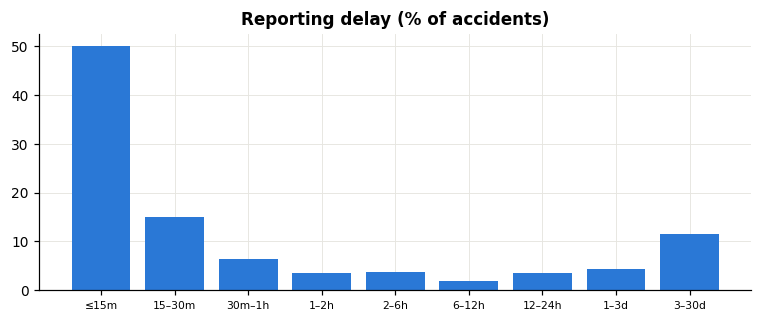

In [19]:
# reporting delay (report time - accident time)
rd = A.reporting_delay_hours
valid = rd.between(0, 24 * 30)
KEY['report_delay'] = {'median_h': round(float(rd[valid].median()), 2), 'over_1h_pct': pct((rd[valid] > 1).mean()),
                       'over_6h_pct': pct((rd[valid] > 6).mean()), 'over_24h_pct': pct((rd[valid] > 24).mean())}
print(KEY['report_delay'])
g = A[valid].assign(dark=A.light_condition.fillna('').str.contains('Night|Darkness'),
                    rural=A.local_body.eq('Gram Panchayat'))
print(g.groupby(['dark', 'rural']).reporting_delay_hours.agg(['size', 'median', lambda s: pct((s > 6).mean())]).rename(columns={'<lambda_0>': '>6h %'}))
fig, ax = plt.subplots(figsize=(7, 3))
bins = [0, .25, .5, 1, 2, 6, 12, 24, 72, 720]
c = pd.cut(rd[valid], bins).value_counts().sort_index()
ax.bar(range(len(c)), c.values / c.sum() * 100, color=BLUE, width=.8)
ax.set_xticks(range(len(c))); ax.set_xticklabels(['≤15m', '15–30m', '30m–1h', '1–2h', '2–6h', '6–12h', '12–24h', '1–3d', '3–30d'], fontsize=7)
ax.set_title('Reporting delay (% of accidents)'); save(fig, '07_reporting_delay')

{'n_with_date': 3104, 'invalid_removed': 111, 'died_within_1h_pct': 41.7, 'died_1_24h_pct': 33.3, 'died_after_24h_pct': 25.0, 'median_h': 2.0}


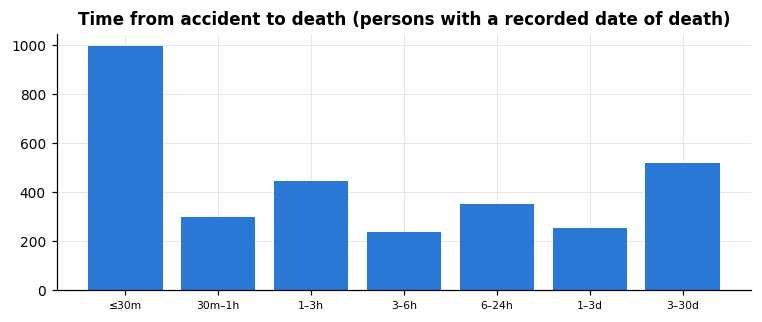

In [20]:
# hours from accident to death (clean: 0 ≤ h ≤ 30 days; negatives are data-entry errors)
dth = pd.concat([D[['hours_accident_to_death']], P[['hours_accident_to_death']], PE[['hours_accident_to_death']]], ignore_index=True).hours_accident_to_death.dropna()
bad = ((dth < 0) | (dth > 720)).sum(); dth = dth[(dth >= 0) & (dth <= 720)]
KEY['death_timing'] = {'n_with_date': int(len(dth)), 'invalid_removed': int(bad),
                       'died_within_1h_pct': pct((dth <= 1).mean()), 'died_1_24h_pct': pct(((dth > 1) & (dth <= 24)).mean()),
                       'died_after_24h_pct': pct((dth > 24).mean()), 'median_h': round(float(dth.median()), 2)}
print(KEY['death_timing'])
fig, ax = plt.subplots(figsize=(7, 3))
c = pd.cut(dth, [-.01, .5, 1, 3, 6, 24, 72, 720]).value_counts().sort_index()
ax.bar(range(len(c)), c.values, color=BLUE, width=.8); ax.set_xticks(range(len(c)))
ax.set_xticklabels(['≤30m', '30m–1h', '1–3h', '3–6h', '6–24h', '1–3d', '3–30d'], fontsize=7)
ax.set_title('Time from accident to death (persons with a recorded date of death)'); save(fig, '08_time_to_death')

In [21]:
# 'unwitnessed' proxy: single-vehicle + night/darkness + rural (Gram Panchayat)
unw = (A.n_veh == 1) & A.light_condition.fillna('').str.contains('Night|Darkness') & A.local_body.eq('Gram Panchayat')
KEY['unwitnessed_proxy'] = {'n': int(unw.sum()), 'pct_of_all': pct(unw.mean()),
                            'fatal_pct': pct((A[unw].severity == 'Fatal').mean()), 'fatal_pct_others': pct((A[~unw].severity == 'Fatal').mean()),
                            'median_report_delay_h': round(float(A.loc[unw & valid, 'reporting_delay_hours'].median()), 2)}
print(KEY['unwitnessed_proxy'])

{'n': 5676, 'pct_of_all': 12.9, 'fatal_pct': 31.9, 'fatal_pct_others': 23.2, 'median_report_delay_h': 0.33}


## 9. Kinematic and mechanical hints

In [22]:
tv = A.traffic_violation.fillna('')
KEY['violation_high_speed_pct'] = pct(tv.str.contains('High Speed').mean())
print('traffic violation mentions High Speed:', KEY['violation_high_speed_pct'], '%')
display(RD.speed_limit_kmph.value_counts().to_frame('Road_Details speed limit (n)'))
print('skid mark recorded Yes:', pct((V.skid_mark == 'Yes').sum() / V.skid_mark.notna().sum()), '% of vehicles with a value')
if 'max_speed_limit_kmph_num' in T:
    display(T.groupby(T.vehicle_type)['max_speed_limit_kmph_num'].describe()[['count', '50%', 'max']].sort_values('count', ascending=False).head(8))
if 'max_speed_limit_kmph_num' in T:
    ms = T.max_speed_limit_kmph_num
    print('implausible vehicle max-speed values (>200 km/h):', int((ms > 200).sum()), 'of', int(ms.notna().sum()))
insp = {c: T[c].value_counts().to_dict() for c in ['speed_limiter_device', 'vlt_device', 'reflective_tapes', 'bull_bars', 'lights_functional']}
for k, v in insp.items(): print(k, v)
KEY['inspection'] = insp

traffic violation mentions High Speed: 18.1 %


,Road_Details speed limit (n)
speed_limit_kmph,
40 -60,2368
Below 40,2120
60-80,890
Not Available,179
80-90,138
Above 90,35


skid mark recorded Yes: 9.5 % of vehicles with a value


,count,50%,max
vehicle_type,,,
Two Wheeler,12060.0,95.0,785.0
Car/Jeep/Van/Taxi,8739.0,130.0,265.0
Truck/Lorry,3995.0,80.0,731.0
Others,1471.0,60.0,600.0
Auto Rickshaw,1341.0,50.0,180.0
Bus,759.0,80.0,200.0
Tempo/Tractor,379.0,50.0,150.0
Construction Vehicle,177.0,60.0,100.0


implausible vehicle max-speed values (>200 km/h): 216 of 29071
speed_limiter_device {'Not Known': 1310, 'No': 1192, 'Yes': 506}
vlt_device {'Not Known': 18708, 'No': 9842, 'Yes': 424}
reflective_tapes {'No': 1867, 'Yes': 1568}
bull_bars {'No': 4160, 'Yes': 302}
lights_functional {'Yes': 4812, 'No': 3190}


## 10. Consistency checks (logged by the parser)

In [23]:
un = VI[VI.issue.str.startswith('label not in schema')].groupby(['sheet', 'field']).size().sort_values(ascending=False)
print('labels found in PDFs but not in the parser schema (kept in Validation_Issues):'); display(un.head(12).to_frame('n'))
vi = VI.groupby(['level', 'issue']).size().sort_values(ascending=False).head(15).to_frame('n'); display(vi)
sev_mis = ((A.severity == 'Fatal') & (A.killed_total == 0)).sum() + ((A.killed_total > 0) & (A.severity != 'Fatal')).sum()
KEY['severity_vs_killed_mismatch'] = int(sev_mis); print('severity vs killed mismatches:', sev_mis)

labels found in PDFs but not in the parser schema (kept in Validation_Issues):


n
sheet             field                         
Road Details      RO                        1427
                  Project Name              1427
                  PIU                       1427
                  UPC                       1427
                  State                     1427
                  Junction Control           356
                  Junction Type              356
                  Horizontal Curve           314
Transport Details Modification Description   145
Passenger         Passport Number             14
Road Details      Vertical Curve              13

n
level   issue                                                              
info    value starts with previous vehicle's make & model (source...  16222
warning label not in schema (value kept only here)                     8333
info    weather 'Sunny' recorded with light condition Night            8304
        value not numeric                                              6389
        declared vehicles 2 != vehicle records in report 1              247
        date not in a recognised format (typed column blank)            182
error   error: no accident id found                                     147
warning 1 killed but severity is not Fatal                               63
info    declared vehicles 1 != vehicle records in report 2               14
error   error: PdfminerException: Unexpected EOF                         12
info    declared vehicles 3 != vehicle records in report 1                6
        declared vehicles 3 != vehicle records in report 2                5
warning severity Fatal but 0 killed in casualty table                     4
        date of death before accident date                                3
info    duplicate (identical content); kept D:\DataSet\2024\nov\a...      3

severity vs killed mismatches: 68


## 11. Save headline numbers

In [24]:
def clean(o):
    if isinstance(o, dict): return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return o
json.dump(clean(KEY), open(f'{OUT}/key_numbers.json', 'w'), indent=2, default=str)
print(json.dumps(clean(KEY), indent=1, default=str)[:6000])

{
 "pdf_files": 44928,
 "accidents_kept": 44114,
 "duplicates": 655,
 "parse_errors": 159,
 "verify_cells": 44768,
 "verify_missing": 0,
 "form_tier_pct": {
  "full (with transport inspection)": 47.1,
  "medium (vehicles/persons)": 37.3,
  "skeletal (accident summary only)": 15.5
 },
 "years": {
  "2023": 9777,
  "2024": 11331,
  "2025": 15991,
  "2026": 7014
 },
 "irad_2023_vs_morth_ratio": 1.32,
 "irad_2023_deaths": 3237,
 "irad_2023_death_coverage_vs_morth": 0.982,
 "geo": {
  "zero_zero": 1,
  "inside_assam_pct": 100.0,
  "coords_reused_5plus": 0,
  "accidents_on_reused_coords": 0
 },
 "hotspots_100m": {
  "cells_with_5plus": 567,
  "accidents_in_them": 3821,
  "share_pct": 8.7
 },
 "field_reliability_usable_pct": {
  "T.speed_limiter_device": 5.8,
  "T.reflective_tapes": 11.6,
  "T.lights_functional": 27.1,
  "T.accident_due_to": 29.1,
  "T.vlt_device": 34.8,
  "D.cell_phone_while_driving": 36.9,
  "D.seatbelt_helmet": 42.8,
  "D.drunk_driving": 46.5,
  "A.initial_observation": 67

## 12. Observations (relevant to our aim)

Numbers below come from the executed cells above (also saved in `eda_outputs/key_numbers.json`).

### A. Can we trust it? (provenance and coverage)
- **44,928 PDFs → 44,114 unique accidents.** 655 duplicate files were removed and 159 PDFs were unreadable (147 without an accident ID, 12 corrupt). An independent re-check of 300 random reports against the PDF text found **0 of 44,768 cells missing**.
- **Period:** Jan 2023 – May 2026. 2026 covers only five months.
- **Representativeness is strong where it matters most.** iRAD records **3,237 people killed in 2023**, against MoRTH's official **3,296 Assam road deaths**, a **~98%** match. Total accidents are higher than MoRTH's (9,777 vs 7,421) because iRAD also holds no-injury and minor reports.
- **Completeness varies by report:**
  - 47% of reports are *full* (with the mechanical transport inspection)
  - 37% are *medium* (vehicles and persons, but no inspection)
  - **15.5% are *skeletal*** (accident summary only; road, weather and light blank)

  Any model must handle missing sections explicitly.
- **Geography:** 37 district labels; Guwahati City, Nagaon, Kamrup, Golaghat and Cachar together hold 38.5%. Coordinates are essentially all inside Assam (one 0,0 point). About 570 hotspot cells of roughly 100 m hold ~9% of all accidents. The busiest is in west Guwahati (Jalukbari area, near the Saraighat corridor studied by Maurya et al.).

### B. Field reliability: what an AI can and cannot learn from
- **Reliable (≥85% usable):** accused/victim role, hospitalisation delay, light, weather, visibility band, road class, vehicle damage side, collision nature.
- **Unreliable:**
  - cell-phone use: 37% usable
  - helmet/seatbelt: 43%
  - drunk driving: 47%
  - speed limiter: 6%
  - reflective tape: 12%
  - "accident due to": 29%, mostly "opinion cannot be given"

  **Behaviour and mechanical-cause fields cannot be training labels**. They must come from sensors or other data. This is the core argument for our physical-AI component.
- **Correction to an earlier assumption:** visibility is a **5-option dropdown** (15 / 25 / 50 / 75 / 100 m), not free guesses. It is still an unmeasured, coarse estimate.
- **Default-value artefacts:**
  - "Sunny / Clear" appears in **60% of night/darkness crashes** (it means "clear")
  - "15–30 minutes" hospitalisation delay covers **~75% of injured persons** (a probable dropdown default)

  Treat both as low-resolution.

### C. What happens: the target classes
- **Most lethal collision types:** vehicle-to-pedestrian (38% fatal) and vehicle-to-bicycle (34%). **Hit from back is the deadliest collision nature (32% fatal, 12,093 crashes)**, ahead of head-on (26%).
- **Top two-vehicle configurations:** 2W–car head-on (1,274), 2W–2W head-on (1,215), 2W–car rear (1,052), 2W–car side (914), 2W–2W rear (862, **38% fatal**), **2W–truck rear (644, 45% fatal)** and **2W–truck head-on (427, 46% fatal)**.
- **Single-vehicle crashes:**
  - the largest group is a **two-wheeler hitting a pedestrian (4,757; 33% fatal)**
  - **two-wheeler into an object or property: 1,165, 46% fatal**
  - two-wheeler with no collision (self-fall or skid): 1,350, 28% fatal
  - fall while boarding or alighting: 356, 35% fatal
- **Conditions:**
  - darkness with no street light is the deadliest light condition (35% fatal, vs 23% in daylight); twilight is 30%
  - smoke/dust (32%) and mist/fog (29%) are more lethal than clear weather (25%)
  - fog peaks in winter months
  - village roads have the highest fatal share (32%)

### D. Two-wheelers (lead concept: "Speed-Breaker or Crash?", Rearview Guardian)
- Two-wheelers are in **46% of all accidents and 57% of fatal accidents**.
- They are **41.5% of crash-involved vehicles vs 69% of the registered fleet**. Quasi-induced exposure puts their involvement ratio at **0.52**: two-wheelers are mostly **victims** in two-vehicle crashes. **Trucks (3.2)** and **buses (2.4)** are strongly over-represented as the at-fault party.
- **What hits a two-wheeler:** cars (3,509 crashes, 22% fatal), other two-wheelers (2,891, 27%), and **trucks (1,678, 43% fatal)**. Rear impacts by trucks are the most lethal pattern.
- **Riders killed or grievously injured:** **49% have a head injury**. The helmet field is "Not Known" for 46% of riders. Where it is recorded, **no-helmet riders were fatal in 19.7% of cases vs 11.6% with a helmet** (an association, subject to reporting bias).
- **Pillion riders:** 7,485 recorded, **18.5% fatal**.
- **For the crash-detection AI:** the target crash modes to detect are:
  - rear impact (by a car or truck)
  - head-on
  - side impact
  - self-fall/skid with no other vehicle
  - hitting a fixed object
  - fall while boarding

  The main non-crash confounders (braking, bumps) must come from lab and public IMU data, because iRAD has no motion signals.

### E. After the crash: the value of an automatic alert
- **Getting killed/grievous victims to hospital:** **private vehicle (40%)**, 108 ambulance (30%), police (12%), private ambulance (12%).
- **Time to death** (3,104 persons with a valid date of death, about 30% of fatalities):
  - **42% died within 1 hour**
  - **33% between 1 and 24 hours**
  - **25% after 24 hours**
  - median 2 hours

  **Most deaths happen after the first hour**, the window where faster alerting and care can matter.
- **Reporting delay:** the median is 16 minutes, but **21% of reports come more than 6 hours after the crash** and 16% more than a day later. Some of this is administrative back-entry, so it's an upper bound on real "unnoticed" time.
- **The "unwitnessed" proxy** (single vehicle + night/darkness + rural gram panchayat): **12.9% of accidents**, **32% fatal vs 23% for the rest**. These are the crashes an automatic alert is for.

### F. Kinematic and mechanical hints (and their limits)
- "High speed" is named in 18% of traffic-violation entries. Skid marks are recorded for only ~10% of vehicles, and only as yes/no.
- **Road Details speed limits** are available for 5,730 reports. Most are 40–60 km/h or below 40.
- The vehicle "max speed" field has implausible values (e.g. 785 km/h). Use it with caution.
- **iRAD contains no speeds, headways or decelerations.** These must come from our CE 323 measurements and published Assam data (Saraighat NH-31). This is the justification for the multi-source design.
- **Parser schema gaps:** Road Details sometimes carries NHAI project fields (RO / PIU / UPC / Project Name, 1,427 reports) and junction and curve attributes. They are kept in Validation_Issues, and can be added to the schema later if useful (e.g. horizontal curve for scenario geometry).

### G. What this means for the project
1. **Lead concept holds.** Two-wheelers dominate deaths, crashes are often unwitnessed, and most deaths happen after the first hour. That gives a clear, quantified *need* for reliable automatic crash detection.
2. **Training design:**
   - **iRAD supplies the crash-mode taxonomy and its frequencies and severities**, used as class priors and to weight synthetic crash pulses. It also supplies post-crash outcomes (the value metric).
   - **It cannot supply motion.** Motion comes from lab data, public IMU data and physics-based synthesis.
3. **Headline candidates for slides:**
   - "2W in 57% of fatal crashes"
   - "Truck-rear-impact on a 2W: 45% fatal"
   - "42% of deaths occur within the first hour"
   - "iRAD matches 98% of MoRTH's 2023 deaths"
   - "behaviour fields are ≤47% usable"
4. **Caveats to state:** police-recorded fields with dropdown defaults; the time-to-death sample covers ~30% of fatalities; the reporting delay includes administrative lag; the helmet association is not causal.